# East Denmark

In [1]:
library(renv)
renv::init()


Attaching package: ‘renv’


The following objects are masked from ‘package:stats’:

    embed, update


The following objects are masked from ‘package:utils’:

    history, upgrade


The following objects are masked from ‘package:base’:

    autoload, load, remove




- The project is out-of-sync -- use `renv::status()` for details.


In [2]:
knitr::opts_chunk$set(echo = FALSE,message = FALSE,warning = FALSE)
library(pacman)
pacman::p_load(tidyr,
               dplyr,
               ggplot2,
               httr,
               rpart.plot,
               pushoverr,
               caret,
               zoo,
               glue,
               rPref,
               lubridate)

In [3]:
suppressMessages({ library(pushoverr)
set_pushover_user(user = Sys.getenv("PUSHOVER_USERKEY"))
set_pushover_app(token = Sys.getenv("PUSHOVER_APPKEY"))

})

In [4]:
# api_url = 'https://api.energidataservice.dk/datastore_search_sql?sql=SELECT "HourDK","SpotPriceDKK","SpotPriceEUR" FROM "elspotprices" WHERE "PriceArea"=\'DK2\' ORDER BY "HourDK" DESC LIMIT 30000'
# api_url = "https://api.energidataservice.dk/dataset/Elspotprices?offset=0&filter=%7B%22PriceArea%22:[%22DK2%22]%7D&sort=HourUTC%20DESC&timezone=dk&limit=35000"
api_url = "https://api.energidataservice.dk/dataset/Elspotprices?offset=0&sort=HourUTC%20DESC&timezone=dk&limit=70000"


api_url = utils::URLencode(api_url)
api_result = httr::GET(api_url)
api_json = rawToChar(api_result$content)
df <- jsonlite::fromJSON(api_json)$records

In [5]:
# api_url = 'https://api.energidataservice.dk/datastore_search_sql?sql=SELECT "HourDK","SpotPriceDKK","SpotPriceEUR" FROM "elspotprices" WHERE "PriceArea"=\'DK2\' ORDER BY "HourDK" DESC LIMIT 30000'
# api_url = "https://api.energidataservice.dk/dataset/Elspotprices?offset=0&filter=%7B%22PriceArea%22:[%22DK2%22]%7D&sort=HourUTC%20DESC&timezone=dk&limit=35000"
api_url = "https://api.energidataservice.dk/dataset/Elspotprices?offset=0&sort=HourUTC%20DESC&timezone=dk&limit=70000"


api_url = utils::URLencode(api_url)
api_result = httr::GET(api_url)
api_json = rawToChar(api_result$content)
df <- jsonlite::fromJSON(api_json)$records
df = df %>% 
  filter(PriceArea=="DK2") %>% 
  dplyr::mutate(HourDK=ymd_hms(HourDK,tz = "Europe/Copenhagen"),
                SpotPriceDKK=SpotPriceDKK/1000,
                SpotPriceEUR=SpotPriceEUR/1000) %>% 
  dplyr::mutate(ExchangeRate=SpotPriceDKK/SpotPriceEUR) %>% 
  dplyr::mutate(SpotPriceDKK=ifelse(is.na(SpotPriceDKK),SpotPriceEUR*7.43988,SpotPriceDKK)) %>% 
  # Radius nettarif per 30. september 2023, moms 20%, afgift 87.13 ører.
  dplyr::mutate(transport=case_when(month(HourDK) %in% seq(4,9,by=1) & hour(HourDK) %in% seq(0,5,by=1)~12.20,
                                    month(HourDK) %in% seq(4,9,by=1) & hour(HourDK) %in% seq(6,16,by=1)~18.31,
                                    month(HourDK) %in% seq(4,9,by=1) & hour(HourDK) %in% seq(17,20,by=1)~47.60,
                                    month(HourDK) %in% seq(4,9,by=1) & hour(HourDK) %in% seq(21,23,by=1)~18.31,
                                    month(HourDK) %in% c(1,2,3,10,11,12) & hour(HourDK) %in% seq(0,5,by=1)~12.20,
                                    month(HourDK) %in% c(1,2,3,10,11,12) & hour(HourDK) %in% seq(6,16,by=1)~36.61,
                                    month(HourDK) %in% c(1,2,3,10,11,12) & hour(HourDK) %in% seq(17,20,by=1)~109.85,
                                    month(HourDK) %in% c(1,2,3,10,11,12) & hour(HourDK) %in% seq(21,23,by=1)~36.61,
                TRUE~as.numeric(NA))) %>% 
  dplyr::mutate(transport=transport*0.8) %>%  # uden moms
  dplyr::mutate(elafgift=72.00) %>% 
  dplyr::mutate(SpotPriceDKK_Total=1.25*(SpotPriceDKK+transport/100+elafgift/100)) %>% 
  dplyr::mutate(SpotPriceDKK_Total_SansAfgift=1.25*(SpotPriceDKK+transport/100)) %>% 
  dplyr::mutate(SpotPriceDKK_Total_SansAfgiftTransport=1.25*(SpotPriceDKK/100))

In [6]:
df %>% sample_n(50)

HourUTC,HourDK,PriceArea,SpotPriceDKK,SpotPriceEUR,ExchangeRate,transport,elafgift,SpotPriceDKK_Total,SpotPriceDKK_Total_SansAfgift,SpotPriceDKK_Total_SansAfgiftTransport
<chr>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2025-06-11T10:00:00,2025-06-11 12:00:00,DK2,0.02088548,0.00280,7.459100,14.648,72,1.1092068,0.20920685,0.0002610685
2024-09-19T20:00:00,2024-09-19 22:00:00,DK2,0.66384003,0.08897,7.461392,14.648,72,1.9129000,1.01290003,0.0082980003
2025-05-25T00:00:00,2025-05-25 02:00:00,DK2,0.09831489,0.01318,7.459400,9.760,72,1.1448936,0.24489362,0.0012289362
2024-10-30T06:00:00,2024-10-30 07:00:00,DK2,0.74344000,0.09968,7.458266,29.288,72,2.1954000,1.29540000,0.0092930000
2025-05-05T02:00:00,2025-05-05 04:00:00,DK2,0.55944114,0.07497,7.462200,9.760,72,1.7213014,0.82130143,0.0069930143
2025-02-07T13:00:00,2025-02-07 14:00:00,DK2,0.66580500,0.08925,7.460000,29.288,72,2.0983563,1.19835625,0.0083225625
2025-05-16T19:00:00,2025-05-16 21:00:00,DK2,1.06815138,0.14318,7.460200,14.648,72,2.4182892,1.51828923,0.0133518923
2025-07-06T16:00:00,2025-07-06 18:00:00,DK2,0.80116275,0.10737,7.461700,38.080,72,2.3774534,1.47745344,0.0100145344
2025-09-06T09:00:00,2025-09-06 11:00:00,DK2,0.06912405,0.00926,7.464800,14.648,72,1.1695051,0.26950506,0.0008640506


## Best Upcoming

Warning message:
“Using one column matrices in `filter()` was deprecated in dplyr 1.1.0.
ℹ Please use one dimensional logical vectors instead.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


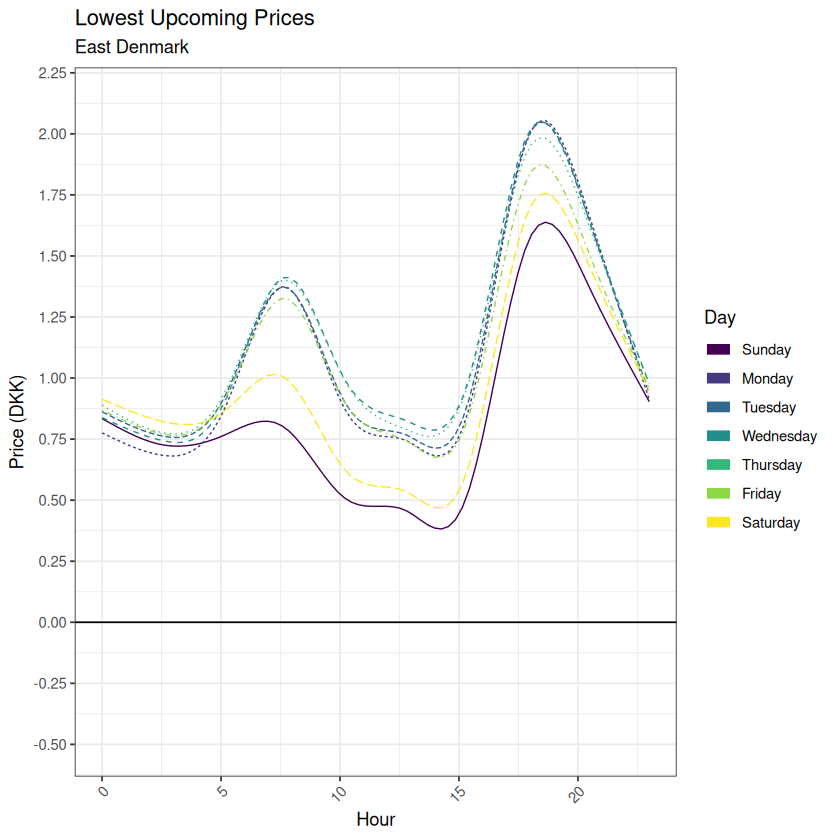

In [7]:
df_previous = df %>% 
  dplyr::mutate(Day=wday(HourDK,label=TRUE,abbr=FALSE),
                Hour=hour(HourDK)) %>% 
  dplyr::mutate(Day=factor(Day)) %>% 
  dplyr::select(Day,
                Hour,
                SpotPriceDKK_Total_SansAfgift)

max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = Sys.time()

lwr_upr = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(SpotPriceDKK_z=scale(SpotPriceDKK_Total)) %>% 
  filter(SpotPriceDKK_z<=0) %>% 
  dplyr::mutate(Cheap="Cheap")

p1 = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day=wday(HourDK,label=TRUE,abbr=FALSE)) %>% 
  dplyr::mutate(HourDK=hour(HourDK)) %>% 
  dplyr::mutate(Day=factor(Day)) %>% 
  ggplot(.,aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgift,color=Day)) +
  geom_line(size=3) +
  # geom_line(data=lwr_upr,aes(x=HourDK,y=SpotPriceDKK_Total,color=Cheap),size=2) +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total),linetype=2) +
  # geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgiftTransport),linetype=4) +
  geom_hline(yintercept = 0) +
  # scale_x_datetime(date_breaks = "1 hour",date_labels = "%H") +
  scale_y_continuous(limits=c(-0.5,NA),breaks = seq(-1,10,by=0.25)) +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  # geom_vline(xintercept = Sys.time(),linetype=2,alpha=0.7)  +
  labs(title="Lowest Upcoming Prices",
       subtitle="East Denmark",
       x="Hour",
       y="Price (DKK)") +
  # theme(legend.position="null") +
  geom_smooth(data=df_previous,aes(x=Hour,y=SpotPriceDKK_Total_SansAfgift,linetype=Day),alpha=0,size=0.4)
p1

## Best Upcoming, All Day

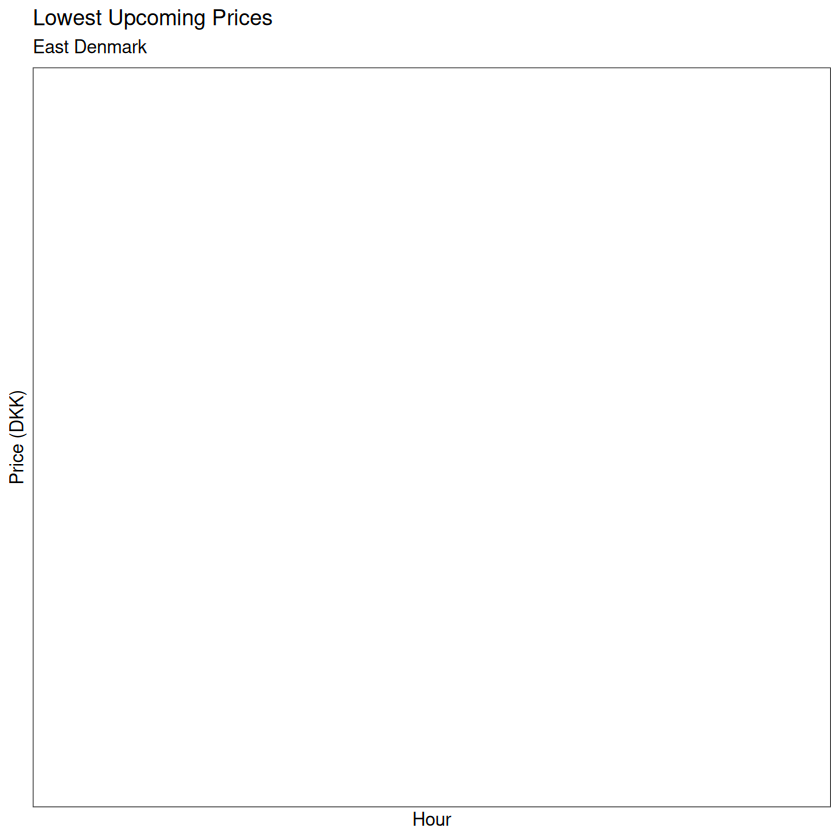

In [8]:
lwr_upr = df %>% 
  filter(HourDK >= Sys.time()) %>% 
  dplyr::mutate(SpotPriceDKK_z=scale(SpotPriceDKK_Total)) %>% 
  filter(SpotPriceDKK_z<=0) %>% 
  dplyr::mutate(Cheap="Cheap")

p2 = df %>% 
  filter(HourDK >= Sys.time()) %>% 
  ggplot(.,aes(x=HourDK,y=SpotPriceDKK_Total)) +
  geom_line() +
  # geom_line(data=lwr_upr,aes(x=HourDK,y=SpotPriceDKK_Total,color=Cheap),size=2) +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgift),linetype=3) +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgiftTransport),linetype=4) +
  # geom_hline(yintercept = 0) +
  scale_x_datetime(date_breaks = "1 hour",date_labels = "%H") +
  scale_y_continuous(limits=c(-0.5,NA),breaks = seq(-1,10,by=0.25)) +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  # geom_vline(xintercept = Sys.time(),linetype=2,alpha=0.7)  +
  labs(title="Lowest Upcoming Prices",
       subtitle="East Denmark",
       x="Hour",
       y="Price (DKK)") +
  theme(legend.position="null")
p2

## Best Two-Hour Window

In [9]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = Sys.time()

max_forecast_day

mean_sd = df %>% 
  filter(as.Date(HourDK)>=Sys.Date()-days(30)) %>% 
    filter(hour(HourDK) >= 6) %>% 
    filter(hour(HourDK) <= 17) %>% 
  dplyr::summarize(mean_=mean(SpotPriceDKK_Total_SansAfgift),sd_=sd(SpotPriceDKK_Total_SansAfgift))

df_windows = lapply(seq(2,5),function(window) {
  
  df %>% 
    filter(HourDK >= max_forecast_day) %>% 
    # filter(hour(HourDK) >= 6) %>% 
    # filter(hour(HourDK) <= 17) %>% 
    arrange(HourDK) %>% 
    dplyr::mutate(rollingsum=zoo::rollsum(x = SpotPriceDKK_Total_SansAfgift,k = window,fill = NA,align = "left"),
    # dplyr::mutate(rollingsum=zoo::rollsum(x = SpotPriceDKK_Total,k = window,fill = NA,align = "left"),
                  window=window) %>% 
    dplyr::mutate(rollingsum=rollingsum/window) %>% 
    dplyr::mutate(p_norm=pnorm(rollingsum,mean=mean_sd$mean_,sd=mean_sd$sd_)) %>% 
  dplyr::mutate(p_label=scales::percent(p_norm,accuracy=1)) %>% 
    na.omit
  
})
df_windows = do.call("rbind",df_windows)

# Consider again the preference from above
p <- low(rollingsum) * high(window)

# Calculate the level-value w.r.t. p by using top-all
res <- psel(df_windows, p, top = nrow(df_windows)) %>% filter(.level==min(.level))
res %>% 
  dplyr::select(HourDK,.level,rollingsum,window,p_norm) %>% 
  knitr::kable()

[1] "2025-09-30 CEST"



|HourDK              | .level| rollingsum| window|    p_norm|
|:-------------------|------:|----------:|------:|---------:|
|2025-09-30 13:00:00 |      1|  0.9915695|      2| 0.5375214|
|2025-09-30 12:00:00 |      1|  0.9954724|      3| 0.5408725|
|2025-09-30 11:00:00 |      1|  1.0179260|      4| 0.5600877|
|2025-09-30 11:00:00 |      1|  1.0315848|      5| 0.5717106|

## Best Two-Hour Window, All Day

In [10]:
mean_sd = df %>% 
  filter(as.Date(HourDK)>=Sys.Date()-days(30)) %>% 
    # filter(hour(HourDK) >= 6) %>% 
    # filter(hour(HourDK) <= 17) %>% 
  dplyr::summarize(mean_=mean(SpotPriceDKK_Total_SansAfgift),sd_=sd(SpotPriceDKK_Total_SansAfgift))

df_windows = lapply(seq(2,5),function(window) {
  
  look_up = data.frame(pct=seq(0,1,by=0.01),
           value = df %>% 
    filter(as.Date(HourDK)>=Sys.Date()-days(30)) %>% 
    arrange(HourDK) %>% 
    dplyr::mutate(rollingsum=zoo::rollsum(x = SpotPriceDKK_Total_SansAfgift,k = window,fill = NA,align = "left"),
                  window=window) %>% 
    dplyr::mutate(rollingsum=rollingsum/window)  %>% 
    pull(rollingsum) %>% 
    quantile(.,seq(0,1,by=0.01),na.rm=T))
  
  df %>% 
    filter(HourDK >= Sys.time()) %>% 
    # filter(hour(HourDK) >= 6) %>% 
    # filter(hour(HourDK) <= 17) %>% 
    arrange(HourDK) %>% 
    dplyr::mutate(rollingsum=zoo::rollsum(x = SpotPriceDKK_Total_SansAfgift,k = window,fill = NA,align = "left"),
                  window=window) %>% 
    dplyr::mutate(rollingsum=rollingsum/window) %>% 
    filter(rollingsum==min(rollingsum,na.rm=T)) %>% 
    # dplyr::mutate(p_norm=pnorm(rollingsum,mean=mean_sd$mean_,sd=mean_sd$sd_)) %>% 
    tidyr::crossing(look_up) %>% 
    filter(rollingsum>=value) %>% 
    filter(pct==max(pct)) %>% 
    dplyr::mutate(p_label=scales::percent(pct,accuracy=1)) %>% 
    na.omit
  
})
df_windows = do.call("rbind",df_windows)

# Consider again the preference from above
p <- low(rollingsum) * high(window)

# Calculate the level-value w.r.t. p by using top-all
res_2 <- psel(df_windows, p, top = nrow(df_windows)) %>% filter(.level==min(.level))
res_2 %>% 
  dplyr::select(HourDK,.level,rollingsum,window,pct) %>% 
  knitr::kable()

Warning message:
“There was 1 warning in `filter()`.
ℹ In argument: `rollingsum == min(rollingsum, na.rm = T)`.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf”
Warning message:
“There was 1 warning in `filter()`.
ℹ In argument: `pct == max(pct)`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf”
Warning message:
“There was 1 warning in `filter()`.
ℹ In argument: `rollingsum == min(rollingsum, na.rm = T)`.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf”
Warning message:
“There was 1 warning in `filter()`.
ℹ In argument: `pct == max(pct)`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf”
Warning message:
“There was 1 warning in `filter()`.
ℹ In argument: `rollingsum == min(rollingsum, na.rm = T)`.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf”
Warning message:
“There was 1 warning in `filter()`.
ℹ In argument: `pct == max(pct)`.
C

Warning message:
“There was 1 warning in `filter()`.
ℹ In argument: `.level == min(.level)`.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf”




|HourDK | .level| rollingsum| window| pct|
|:------|------:|----------:|------:|---:|

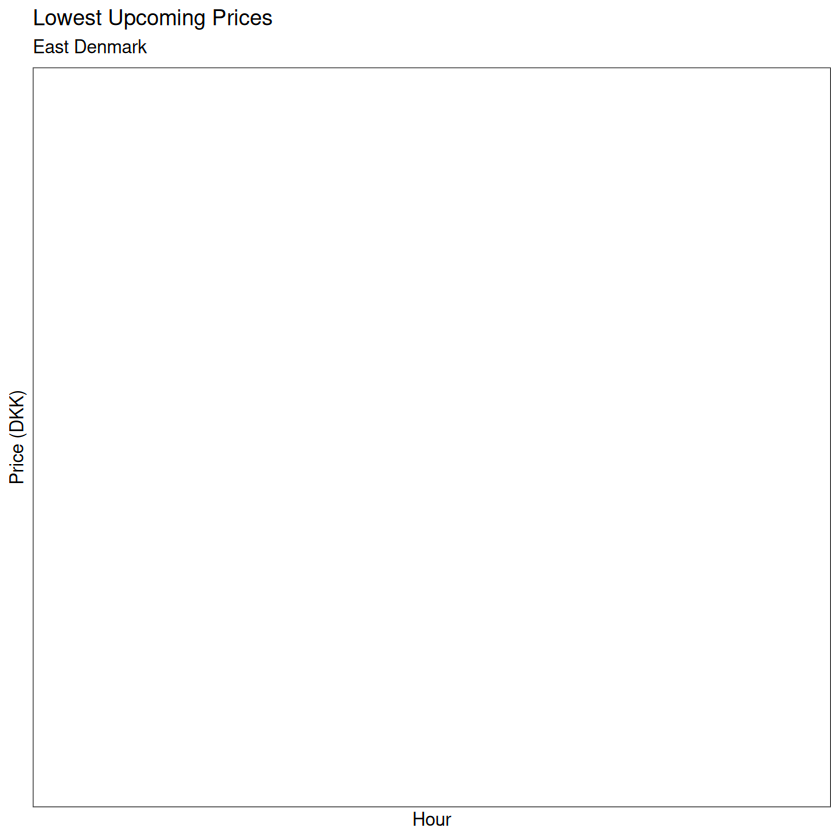

In [11]:
lwr_upr = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(SpotPriceDKK_z=scale(SpotPriceDKK_Total)) %>% 
  filter(SpotPriceDKK_z<=0) %>% 
  dplyr::mutate(Cheap="Cheap")

df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  ggplot(.,aes(x=HourDK,y=SpotPriceDKK_Total)) +
  geom_line() +
  # geom_line(data=lwr_upr,aes(x=HourDK,y=SpotPriceDKK_Total,color=Cheap),size=2) +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgift),linetype=3) +
  # geom_hline(yintercept = 0) +
  scale_y_continuous(limits=c(-1,NA),breaks = seq(-1,10,by=0.25)) +
  scale_x_datetime(date_breaks = "1 hour",date_labels = "%H") +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  # geom_vline(xintercept = Sys.time(),linetype=2,alpha=0.7)  +
  labs(title="Lowest Upcoming Prices",
       subtitle="East Denmark",
       x="Hour",
       y="Price (DKK)") +
  theme(legend.position="null")

## Last Week & Upcoming

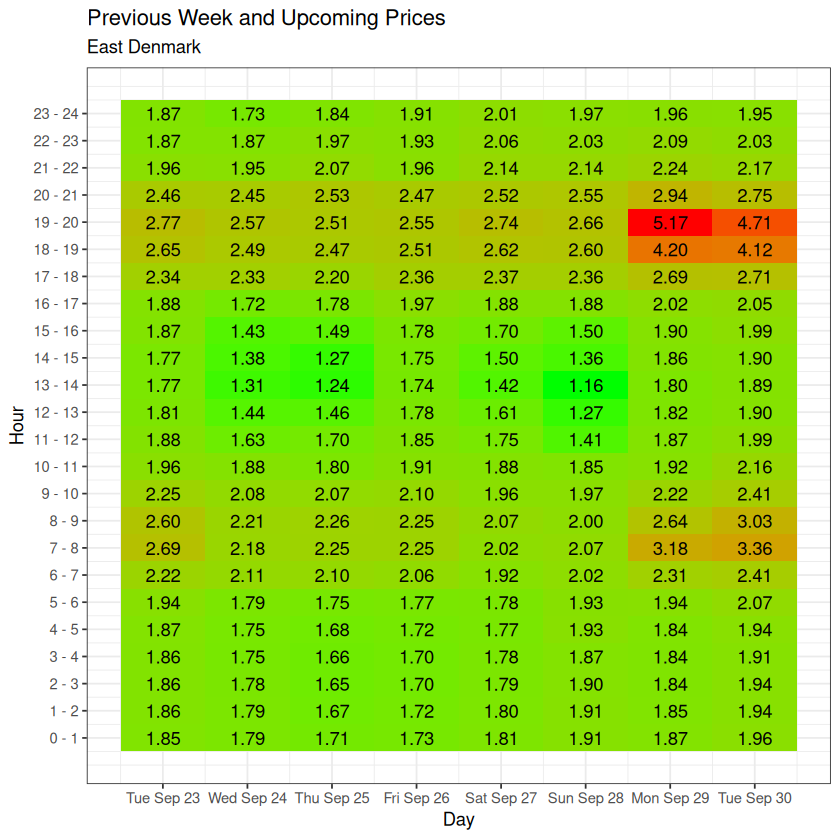

In [12]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-days(7)

df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  ggplot(.,aes(x=Day_Num,y=Hour)) +
  geom_tile(aes(fill=SpotPriceDKK_Total)) +
  scale_fill_gradient(low = "green",high = "red") +
  scale_x_datetime(date_breaks = "1 day",date_labels = "%a %b %d") +
  scale_y_continuous(breaks = seq(0,23,by=1),labels = paste0(seq(0,23,by=1)," - ",seq(1,24,by=1))) +
  theme_bw() +
  geom_text(aes(label=scales::number(SpotPriceDKK_Total,accuracy = 0.01)))  +
  labs(title="Previous Week and Upcoming Prices",
       subtitle="East Denmark",
       x="Day",
       y="Hour") +
  theme(legend.position="null")

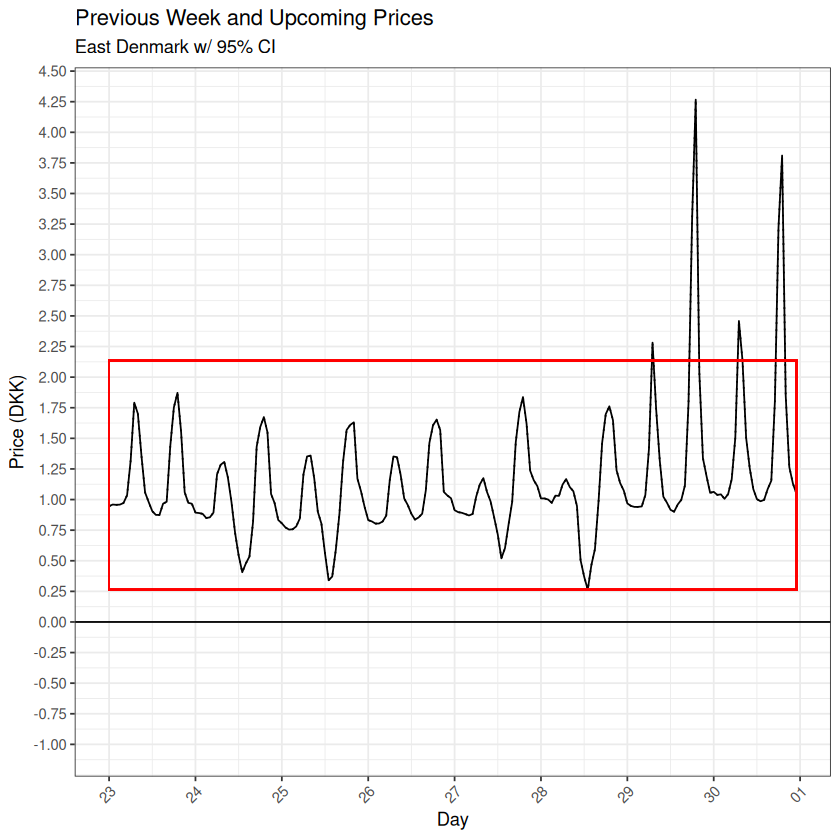

In [13]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-days(7)

lwr_upr = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(SpotPriceDKK_z=scale(SpotPriceDKK_Total_SansAfgift)) %>% 
  filter(SpotPriceDKK_z<=qnorm(p = 0.975) | SpotPriceDKK_z<=qnorm(p = 0.025)) %>% 
  dplyr::summarise(lwr=min(SpotPriceDKK_Total_SansAfgift),upr=max(SpotPriceDKK_Total_SansAfgift))

lwr_upr_date = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::summarise(lwr=min(HourDK),upr=max(HourDK))


df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  ggplot(.,aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgift)) +
  geom_line() +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgift),linetype=3) +
  geom_hline(yintercept = 0) +
  scale_y_continuous(limits=c(-1,NA),breaks = seq(-1,10,by=0.25)) +
  scale_x_datetime(date_breaks = "1 day",date_labels = "%d") +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  geom_vline(xintercept = Sys.time(),linetype=2,alpha=0.7) +
  geom_rect(xmin = lwr_upr_date$lwr,xmax = lwr_upr_date$upr,ymin = lwr_upr$lwr,ymax = lwr_upr$upr,color="red",fill=NA)  +
  labs(title="Previous Week and Upcoming Prices",
       subtitle="East Denmark w/ 95% CI",
       x="Day",
       y="Price (DKK)") +
  theme(legend.position="null")

## Best time spans

`summarise()` has grouped output by 'start', 'stop'. You can override using the
`.groups` argument.


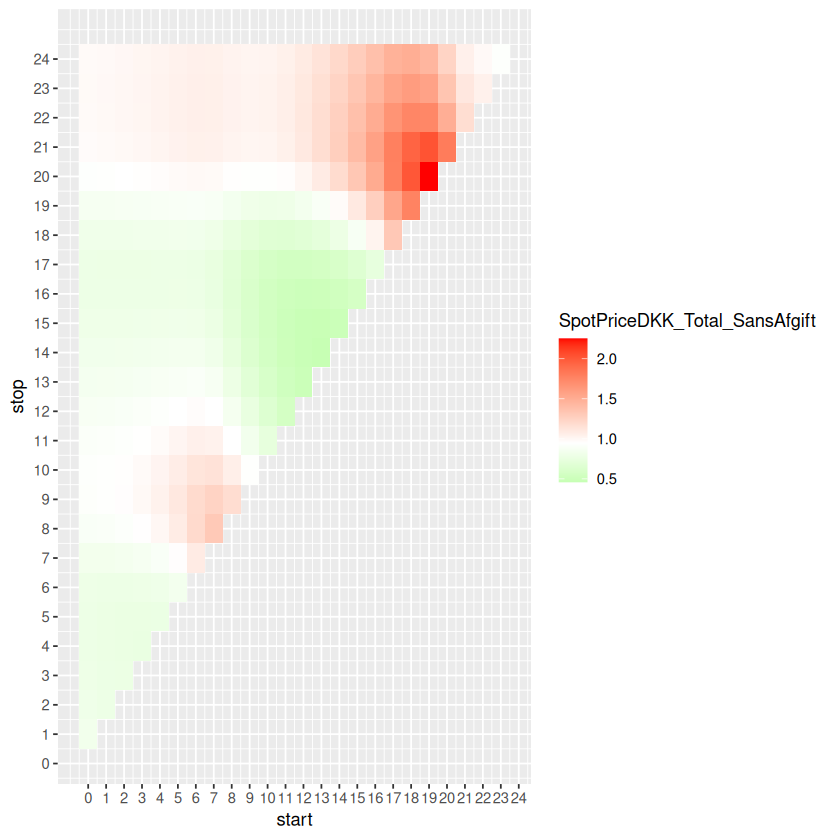

In [14]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-months(1)

mean_price_spot = expand.grid(start=seq(0,23,by=1),
            stop=seq(1,24,by=1)) %>% 
  filter(start<stop) %>% 
  tidyr::crossing(df) %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  filter(Hour>=start,Hour<stop) %>% 
  dplyr::summarize(SpotPriceMean=mean(SpotPriceDKK_Total_SansAfgift)) %>% 
  pull(SpotPriceMean)

expand.grid(start=seq(0,23,by=1),
            stop=seq(1,24,by=1)) %>% 
  filter(start<stop) %>% 
  tidyr::crossing(df) %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  filter(Hour>=start,Hour<stop) %>% 
  dplyr::mutate(SpotPriceMean=mean(SpotPriceDKK_Total_SansAfgift)) %>% 
  group_by(start,stop,SpotPriceMean) %>% 
  dplyr::summarize(SpotPriceDKK_Total_SansAfgift=mean(SpotPriceDKK_Total_SansAfgift,na.rm=T)) %>% 
  ggplot(aes(x=start,y=stop)) +
  geom_tile(aes(fill=SpotPriceDKK_Total_SansAfgift)) +
  scale_fill_gradient2(midpoint = mean_price_spot,low = "green",mid = "white",high = "red") +
  scale_x_continuous(breaks = seq(0,24,by=1)) +
  scale_y_continuous(breaks = seq(0,24,by=1))

`summarise()` has grouped output by 'start', 'stop'. You can override using the
`.groups` argument.


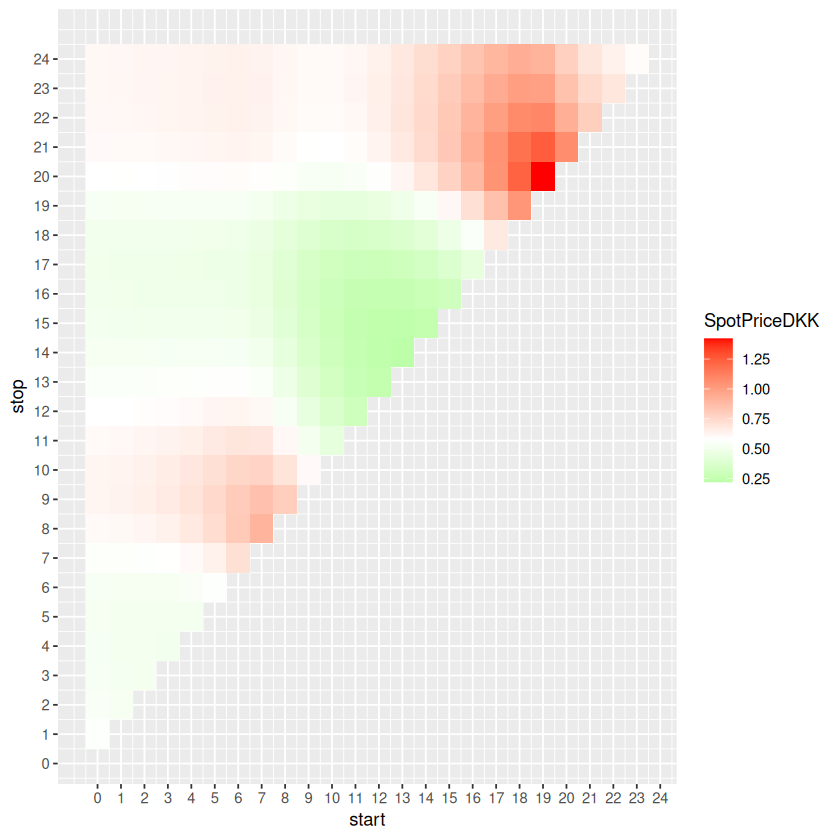

In [15]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-months(1)

mean_price_spot = expand.grid(start=seq(0,23,by=1),
            stop=seq(1,24,by=1)) %>% 
  filter(start<stop) %>% 
  tidyr::crossing(df) %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  filter(Hour>=start,Hour<stop) %>% 
  dplyr::summarize(SpotPriceMean=mean(SpotPriceDKK)) %>% 
  pull(SpotPriceMean)

expand.grid(start=seq(0,23,by=1),
            stop=seq(1,24,by=1)) %>% 
  filter(start<stop) %>% 
  tidyr::crossing(df) %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  filter(Hour>=start,Hour<stop) %>% 
  dplyr::mutate(SpotPriceMean=mean(SpotPriceDKK)) %>% 
  group_by(start,stop,SpotPriceMean) %>% 
  dplyr::summarize(SpotPriceDKK=mean(SpotPriceDKK,na.rm=T)) %>% 
  ggplot(aes(x=start,y=stop)) +
  geom_tile(aes(fill=SpotPriceDKK)) +
  scale_fill_gradient2(midpoint = mean_price_spot,low = "green",mid = "white",high = "red") +
  scale_x_continuous(breaks = seq(0,24,by=1)) +
  scale_y_continuous(breaks = seq(0,24,by=1))

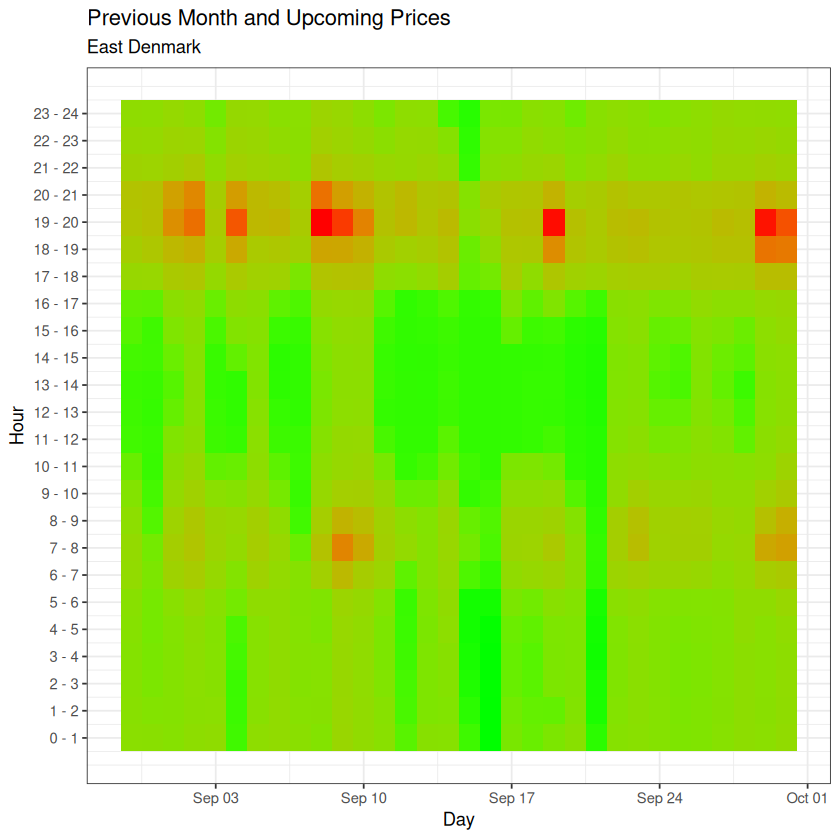

In [16]:
df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  ggplot(.,aes(x=Day_Num,y=Hour)) +
  geom_tile(aes(fill=SpotPriceDKK_Total)) +
  scale_fill_gradient(low = "green",high = "red") +
  scale_x_datetime(date_breaks = "7 day",date_labels = "%b %d") +
  scale_y_continuous(breaks = seq(0,23,by=1),labels = paste0(seq(0,23,by=1)," - ",seq(1,24,by=1))) +
  theme_bw()  +
  labs(title="Previous Month and Upcoming Prices",
       subtitle="East Denmark",
       x="Day",
       y="Hour") +
  theme(legend.position="null")

## Last Month & Upcoming

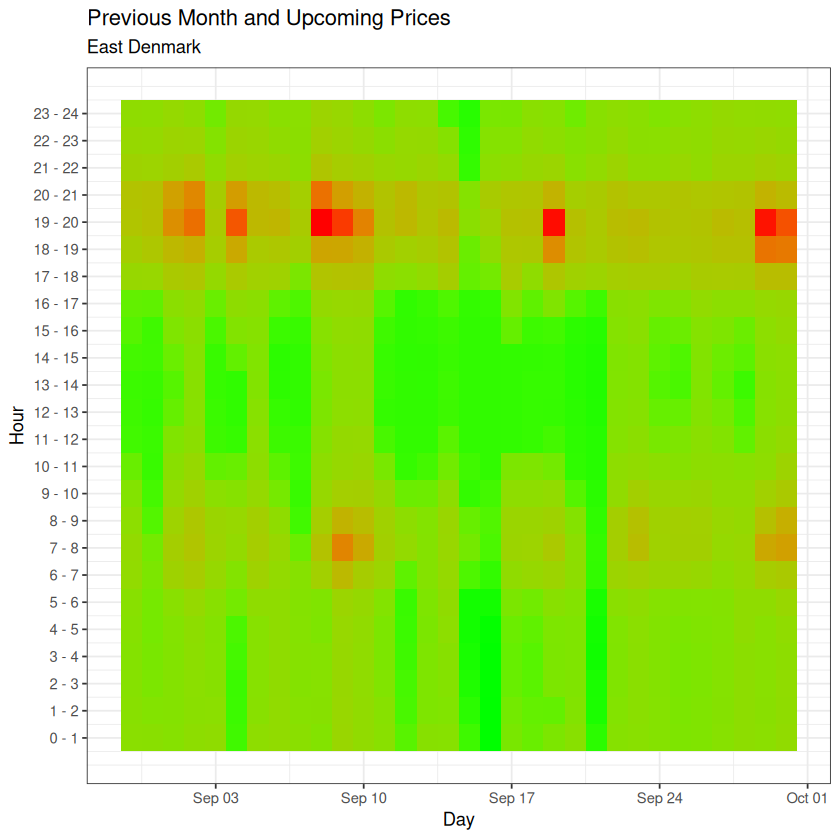

In [17]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-months(1)

df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  ggplot(.,aes(x=Day_Num,y=Hour)) +
  geom_tile(aes(fill=SpotPriceDKK_Total)) +
  scale_fill_gradient(low = "green",high = "red") +
  scale_x_datetime(date_breaks = "7 day",date_labels = "%b %d") +
  scale_y_continuous(breaks = seq(0,23,by=1),labels = paste0(seq(0,23,by=1)," - ",seq(1,24,by=1))) +
  theme_bw()  +
  labs(title="Previous Month and Upcoming Prices",
       subtitle="East Denmark",
       x="Day",
       y="Hour") +
  theme(legend.position="null")

# Box plot

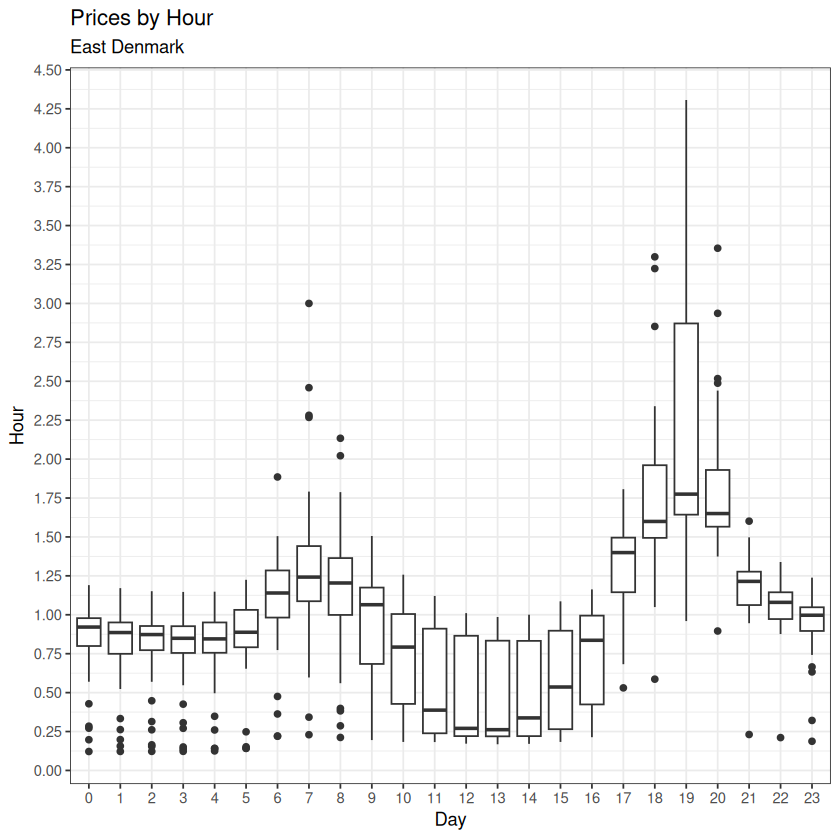

In [18]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-months(1)

df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  dplyr::mutate(Hour=factor(Hour)) %>% 
  ggplot(.,aes(x=Hour,y=SpotPriceDKK_Total_SansAfgift)) +
  geom_boxplot() +
  # geom_violin() +
  scale_y_continuous(breaks = seq(0,10,by=0.25)) +
  theme_bw()  +
  labs(title="Prices by Hour",
       subtitle="East Denmark",
       x="Day",
       y="Hour") +
  theme(legend.position="null")

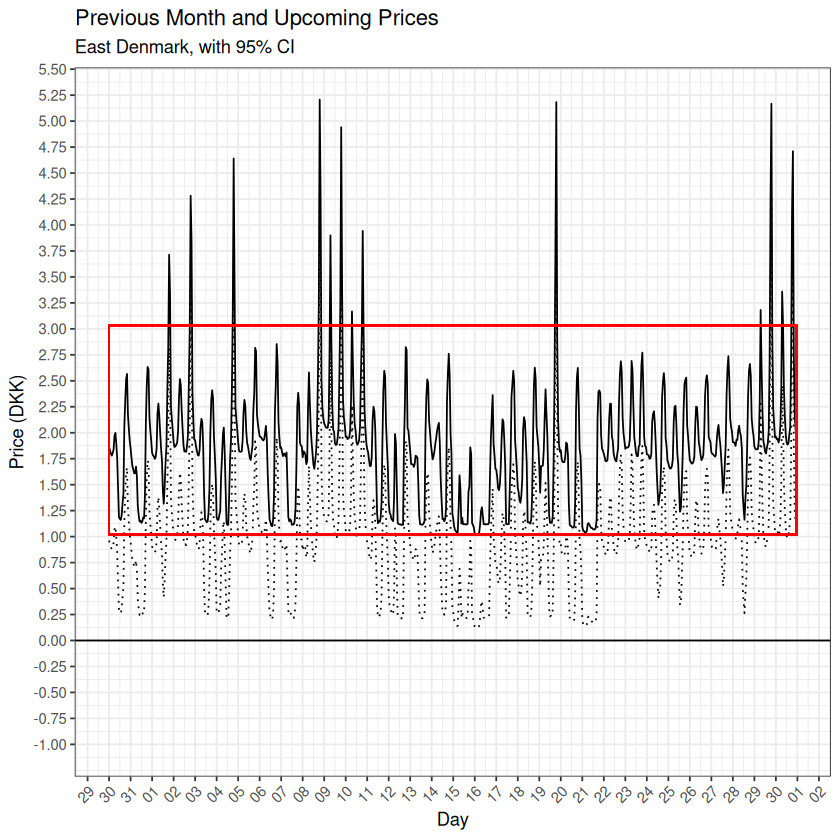

In [19]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-months(1)

lwr_upr = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(SpotPriceDKK_z=scale(SpotPriceDKK_Total)) %>% 
  filter(SpotPriceDKK_z<=qnorm(p = 0.975) | SpotPriceDKK_z<=qnorm(p = 0.025)) %>% 
  dplyr::summarise(lwr=min(SpotPriceDKK_Total),upr=max(SpotPriceDKK_Total))

lwr_upr_date = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::summarise(lwr=min(HourDK),upr=max(HourDK))


df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  ggplot(.,aes(x=HourDK,y=SpotPriceDKK_Total)) +
  geom_line() +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgift),linetype=3) +
  geom_hline(yintercept = 0) +
  scale_y_continuous(limits=c(-1,NA),breaks = seq(-1,10,by=0.25)) +
  scale_x_datetime(date_breaks = "1 day",date_labels = "%d") +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  geom_vline(xintercept = Sys.time(),linetype=2,alpha=0.7) +
  geom_rect(xmin = lwr_upr_date$lwr,xmax = lwr_upr_date$upr,ymin = lwr_upr$lwr,ymax = lwr_upr$upr,color="red",fill=NA) +
  labs(title="Previous Month and Upcoming Prices",
       subtitle="East Denmark, with 95% CI",
       x="Day",
       y="Price (DKK)") +
  theme(legend.position="null")

## All Time

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


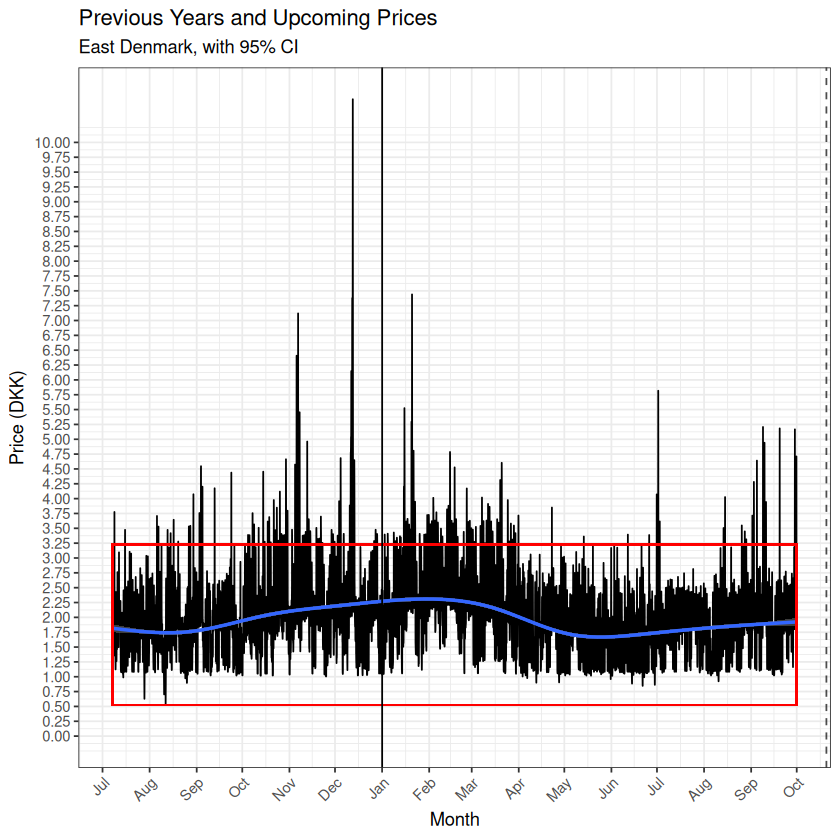

In [20]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = lubridate::floor_date(min(df$HourDK),unit = "day")

lwr_upr = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(SpotPriceDKK_z=scale(SpotPriceDKK_Total)) %>% 
  filter(SpotPriceDKK_z<=qnorm(p = 0.975) | SpotPriceDKK_z<=qnorm(p = 0.025)) %>% 
  dplyr::summarise(lwr=min(SpotPriceDKK_Total),upr=max(SpotPriceDKK_Total)) %>% 
  dplyr::mutate(lwr=ifelse(lwr<0,0,lwr))

lwr_upr_date = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::summarise(lwr=min(HourDK),upr=max(HourDK))


df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  ggplot(.,aes(x=HourDK,y=SpotPriceDKK_Total)) +
  geom_line() +
  geom_smooth() +
  scale_x_datetime(date_breaks = "1 month",date_labels = "%b") +
  scale_y_continuous(limits=c(0,NA),breaks = seq(0,10,by=0.25)) +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  geom_vline(xintercept = Sys.time(),linetype=2,alpha=0.7) +
  geom_rect(xmin = lwr_upr_date$lwr,xmax = lwr_upr_date$upr,ymin = lwr_upr$lwr,ymax = lwr_upr$upr,color="red",fill=NA) +
  labs(title="Previous Years and Upcoming Prices",
       subtitle="East Denmark, with 95% CI",
       x="Month",
       y="Price (DKK)") +
  theme(legend.position="null") +
  geom_vline(xintercept = seq.POSIXt(ymd_hms("2015-01-01 00:00:00"),ymd_hms("2030-01-01 00:00:00"),by = "1 year"))

## Time Windows

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


,.outcome,,,,,,,,,,
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
8,0.25,when,Hour,is,10,to,17,&,Day,is,Sat or Sun
44,0.46,when,Hour,is,9,to,10,&,Day,is,Sat or Sun
72,0.47,when,Hour,is,12,to,16,&,Day,is,Fri or Mon or Thu or Tue or Wed
73,0.57,when,Hour,is,11,to,12,&,Day,is,Fri or Mon or Thu or Tue or Wed
37,0.63,when,Hour,is,16,to,17,&,Day,is,Fri or Mon or Thu or Tue or Wed
90,0.69,when,Hour,is,6,to,9,&,Day,is,Sun
19,0.71,when,Hour,is,10,to,11,&,Day,is,Fri or Mon or Thu or Tue or Wed
10,0.82,when,Hour,<,6,,,,,,
91,0.88,when,Hour,is,6,to,9,&,Day,is,Sat


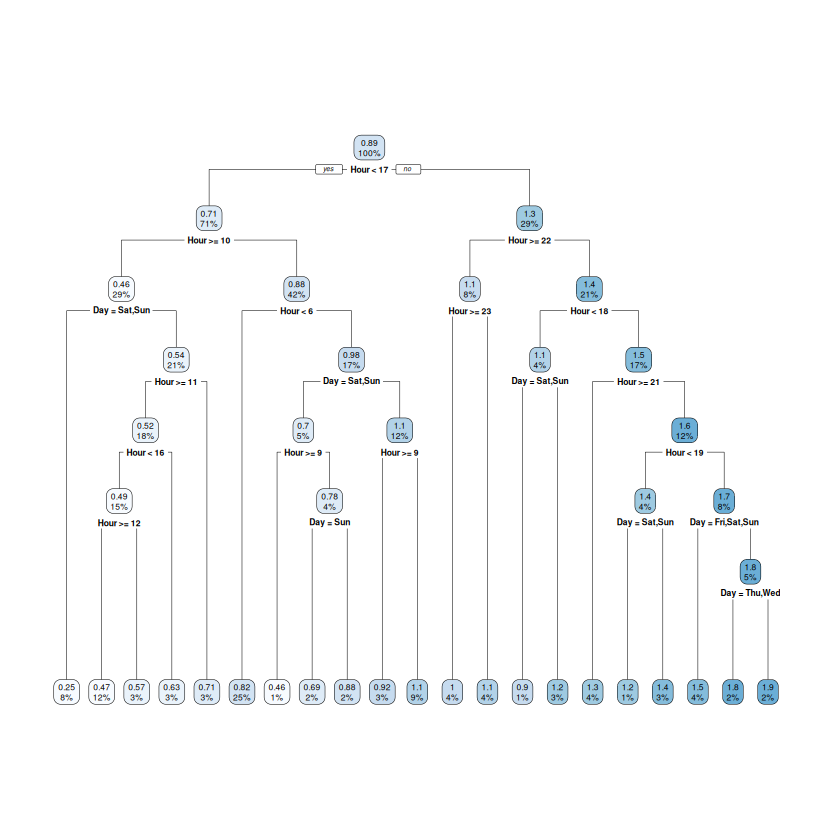

In [21]:
df_predict_all_week = df %>% 
  filter(HourDK >= Sys.Date()-months(6)) %>% 
  dplyr::mutate(Hour = hour(HourDK),
                Day = factor(paste0(wday(HourDK,label = TRUE)))) %>% 
  dplyr::select(SpotPriceDKK_Total_SansAfgift,Hour,Day)

train_control = caret::trainControl(method = "repeatedcv",number = 5,repeats = 5)
fit_rpart = caret::train(y = df_predict_all_week$SpotPriceDKK_Total_SansAfgift,
                         x = df_predict_all_week %>% dplyr::select(-SpotPriceDKK_Total_SansAfgift) %>% as.data.frame(),
                         method = "rpart",
                         tuneLength=50,
                         metric = "RMSE",
                         trControl = train_control)

rpart.plot(fit_rpart$finalModel)
rpart.rules(fit_rpart$finalModel)

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


,.outcome,,,,,,,,,,
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
8,1.1,when,Hour,is,10,to,17,&,Day,is,Sat or Sun
44,1.4,when,Hour,is,9,to,10,&,Day,is,Sat or Sun
36,1.4,when,Hour,is,11,to,16,&,Day,is,Fri or Mon or Thu or Tue or Wed
37,1.5,when,Hour,is,16,to,17,&,Day,is,Fri or Mon or Thu or Tue or Wed
90,1.6,when,Hour,is,6,to,9,&,Day,is,Sun
19,1.6,when,Hour,is,10,to,11,&,Day,is,Fri or Mon or Thu or Tue or Wed
10,1.7,when,Hour,<,6,,,,,,
91,1.8,when,Hour,is,6,to,9,&,Day,is,Sat
28,1.8,when,Hour,is,17,to,18,&,Day,is,Sat or Sun


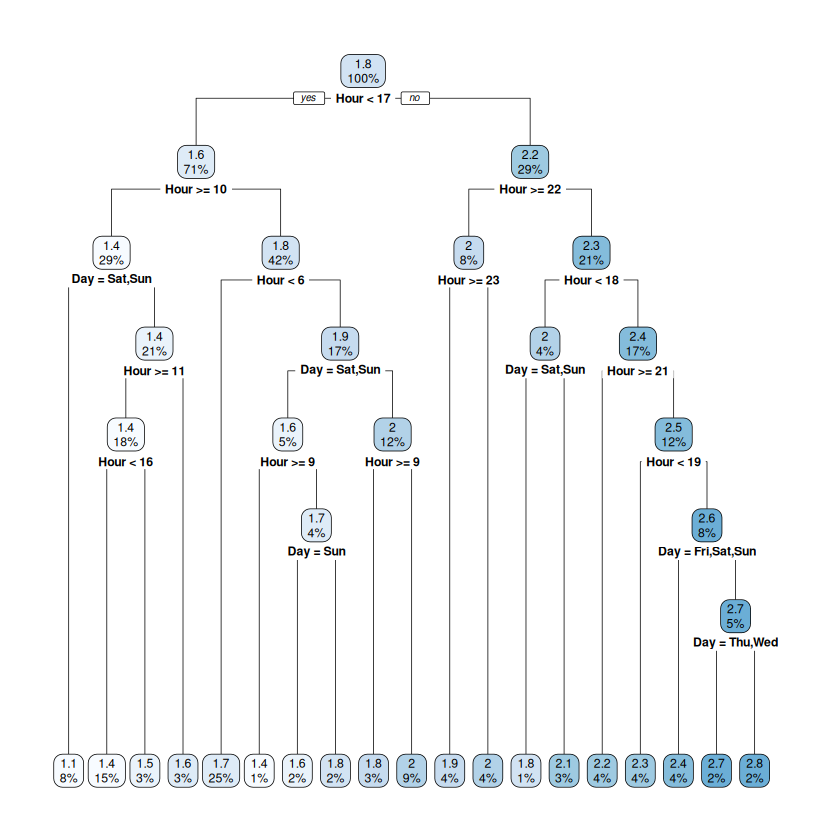

In [22]:
df_predict_all_week = df %>% 
  filter(HourDK >= Sys.Date()-months(6)) %>% 
  dplyr::mutate(Hour = hour(HourDK),
                Day = factor(paste0(wday(HourDK,label = TRUE)))) %>% 
  dplyr::select(SpotPriceDKK_Total,Hour,Day)

train_control = caret::trainControl(method = "repeatedcv",number = 5,repeats = 5)
fit_rpart = caret::train(y = df_predict_all_week$SpotPriceDKK_Total,
                         x = df_predict_all_week %>% dplyr::select(-SpotPriceDKK_Total) %>% as.data.frame(),
                         method = "rpart",
                         tuneLength=50,
                         metric = "RMSE",
                         trControl = train_control)

rpart.plot(fit_rpart$finalModel)
rpart.rules(fit_rpart$finalModel)

# By season

In [23]:
# Analysis of electricity prices by time period and month
library(dplyr)
library(ggplot2)
library(knitr)

# Create time period categories
df_analysis <- df %>%
  filter(!is.na(SpotPriceDKK_Total_SansAfgift)) %>%
  dplyr::mutate(
    Month = month(HourDK, label = TRUE),
    Hour = hour(HourDK),
    TimePeriod = case_when(
      Hour %in% c(22, 23, 0, 1, 2, 3, 4, 5, 6) ~ "Night (22-06)",
      Hour %in% c(11, 12, 13, 14, 15, 16, 17) ~ "Day (11-17)",
      TRUE ~ "Other"
    )
  ) %>%
  filter(TimePeriod != "Other") %>%
  dplyr::select(Month, TimePeriod, SpotPriceDKK_Total_SansAfgift, HourDK)

# Summary table by month and time period
summary_table <- df_analysis %>%
  group_by(Month, TimePeriod) %>%
  dplyr::summarise(
    Count = n(),
    Mean = round(mean(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE), 3),
    Median = round(median(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE), 3),
    Min = round(min(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE), 3),
    Max = round(max(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE), 3),
    SD = round(sd(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE), 3),
    .groups = "drop"
  ) %>%
  arrange(Month, TimePeriod)

summary_table


Month,TimePeriod,Count,Mean,Median,Min,Max,SD
<ord>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Jan,Day (11-17),217,1.543,1.413,0.401,6.539,0.767
Jan,Night (22-06),279,0.861,0.895,0.132,1.874,0.433
Feb,Day (11-17),196,1.546,1.459,0.739,3.886,0.536
Feb,Night (22-06),252,1.144,1.215,0.159,1.866,0.354
Mar,Day (11-17),217,1.022,0.992,0.254,2.702,0.632
Mar,Night (22-06),278,0.962,1.036,0.150,2.025,0.406
Apr,Day (11-17),210,0.519,0.376,0.000,1.487,0.385
Apr,Night (22-06),270,0.950,0.971,0.205,1.609,0.228
May,Day (11-17),217,0.409,0.220,0.060,1.370,0.319


In [24]:

# Calculate differences between day and night prices
price_differences <- df_analysis %>%
  group_by(Month, TimePeriod) %>%
  dplyr::summarise(
    Mean_Price = mean(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  tidyr::pivot_wider(names_from = TimePeriod, values_from = Mean_Price) %>%
  dplyr::mutate(
    Difference = round(`Day (11-17)` - `Night (22-06)`, 3),
    Percent_Diff = round(((`Day (11-17)` - `Night (22-06)`) / `Night (22-06)`) * 100, 1)
  ) %>%
  dplyr::select(Month, `Night (22-06)`, `Day (11-17)`, Difference, Percent_Diff)

price_differences


Month,Night (22-06),Day (11-17),Difference,Percent_Diff
<ord>,<dbl>,<dbl>,<dbl>,<dbl>
Jan,0.8613631,1.5429869,0.682,79.1
Feb,1.1439134,1.5455475,0.402,35.1
Mar,0.9617392,1.0222845,0.061,6.3
Apr,0.9498086,0.5188262,-0.431,-45.4
May,0.8610663,0.4091645,-0.452,-52.5
Jun,0.8238418,0.3297891,-0.494,-60.0
Jul,0.9137585,0.6020333,-0.312,-34.1
Aug,0.9170413,0.5378560,-0.379,-41.3
Sep,0.8165852,0.6430633,-0.174,-21.2


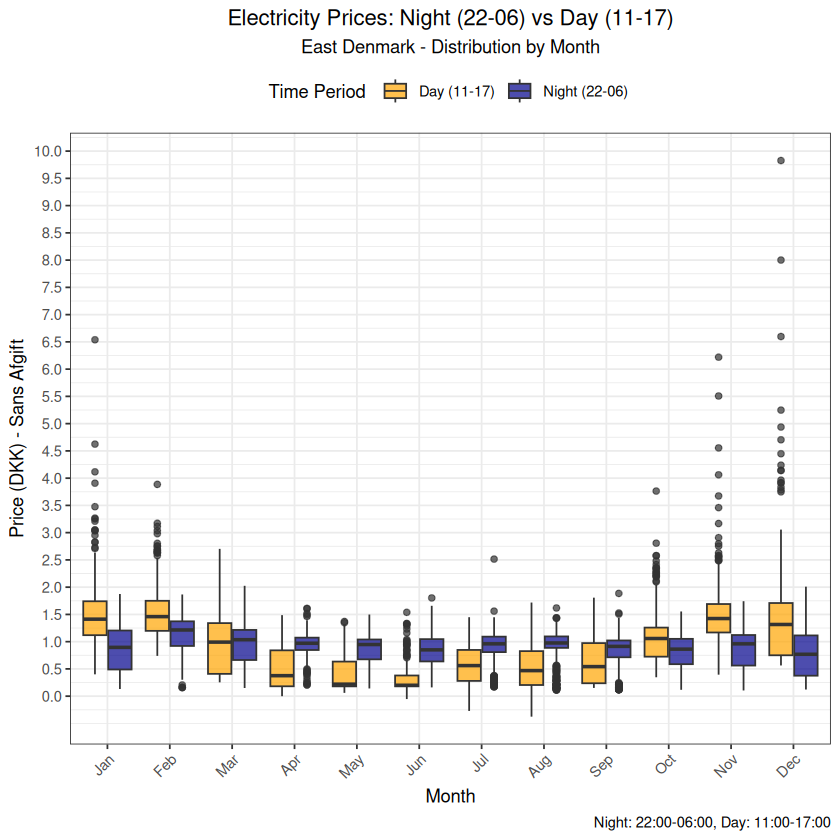

In [25]:

# Create boxplot
boxplot_analysis <- ggplot(df_analysis, aes(x = Month, y = SpotPriceDKK_Total_SansAfgift, fill = TimePeriod)) +
  geom_boxplot(position = position_dodge(width = 0.8), alpha = 0.7) +
  scale_fill_manual(values = c("Night (22-06)" = "darkblue", "Day (11-17)" = "orange")) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "top",
    plot.title = element_text(hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5)
  ) +
  labs(
    title = "Electricity Prices: Night (22-06) vs Day (11-17)",
    subtitle = "East Denmark - Distribution by Month",
    x = "Month",
    y = "Price (DKK) - Sans Afgift",
    fill = "Time Period",
    caption = "Night: 22:00-06:00, Day: 11:00-17:00"
  ) +
  scale_y_continuous(breaks = seq(0, ceiling(max(df_analysis$SpotPriceDKK_Total_SansAfgift, na.rm = TRUE)), by = 0.5))

boxplot_analysis


Available historical data: 2024-07-07 to 2025-09-30 
Total days of data: 450 
Analyzing 30-day periods starting from: 2025-10-20 



Overall 30-day forward-looking statistics:
  Total_Periods Mean_Day_Median Mean_Night_Median Mean_Difference
1           422           0.658             0.927          -0.269
  Mean_Percent_Diff Max_Difference Min_Difference
1               -24           0.67          -0.81

Seasonal analysis (by period start season):
# A tibble: 4 × 6
  Season Periods Mean_Day Mean_Night Mean_Difference Mean_Percent_Diff
  <chr>    <int>    <dbl>      <dbl>           <dbl>             <dbl>
1 Winter      90    1.18       0.911           0.271              40.6
2 Fall        92    1.00       0.829           0.172              23.1
3 Summer     148    0.351      0.977          -0.627             -64.3
4 Spring      92    0.297      0.961          -0.664             -69.5

Best 30-day periods for Night prices (lowest):
              Period_Label Weekday_Start Night_30Day_Median Day_30Day_Median
1 2024-12-10 to 2025-01-08       Tuesday          0.3804562        0.9214125
2 2024-12-11 to 2025-01-09     We

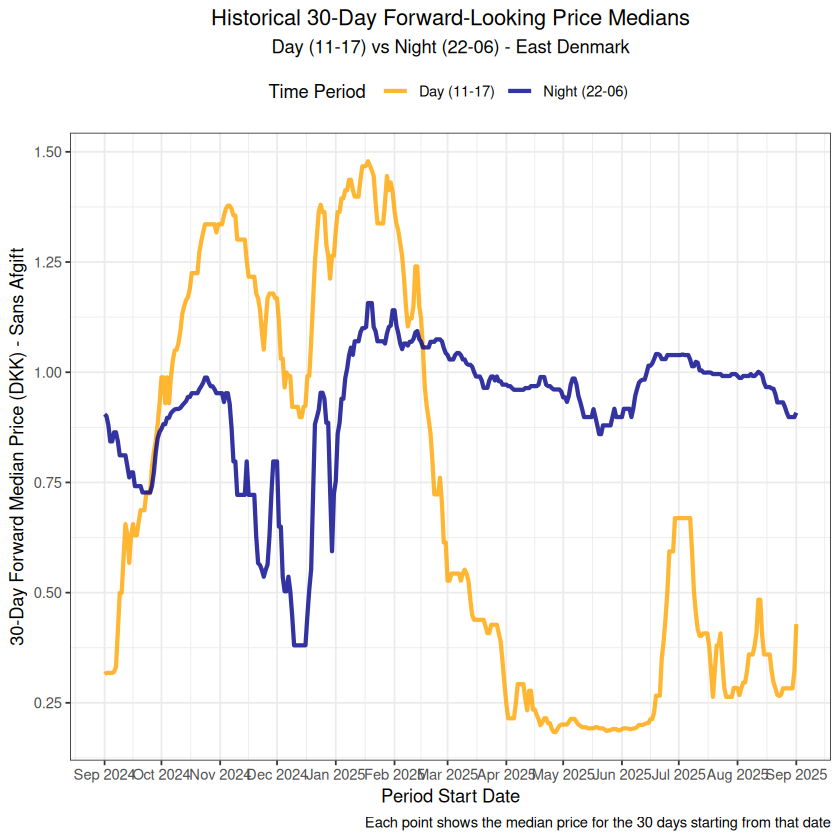

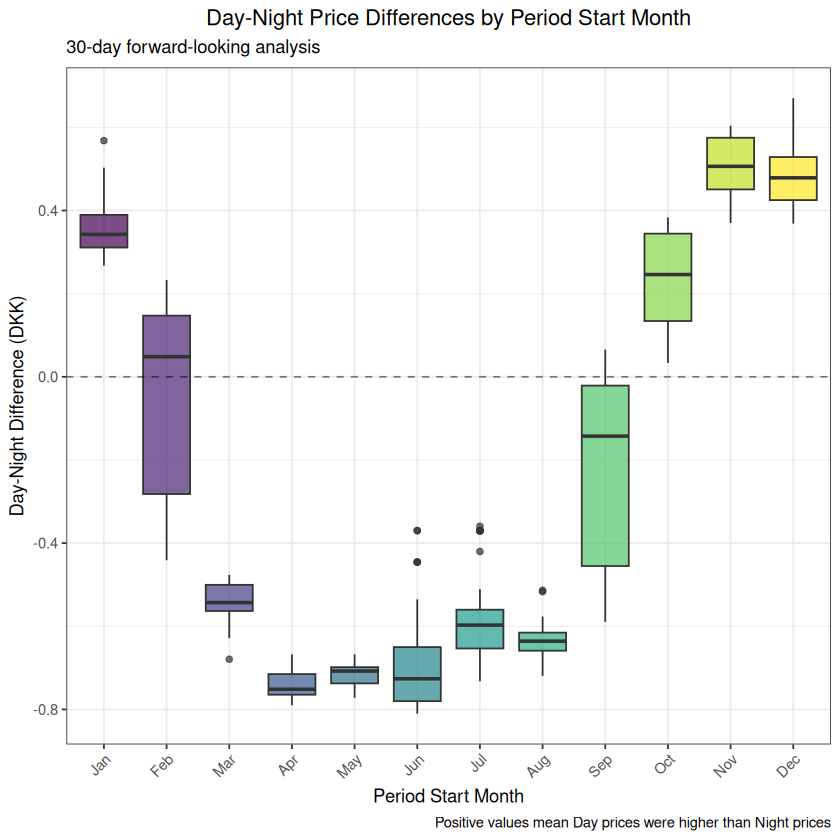

In [26]:
# 30-Day Forward-Looking Historical Analysis
# This analysis looks at historical data to understand what Day vs Night prices
# looked like for 30-day periods starting from any given date

library(zoo)
library(dplyr)
library(ggplot2)
library(lubridate)

# Set the analysis start date (the date you're "standing on")
analysis_start_date <- Sys.Date()  # Change this to any historical date

# Check available historical data
data_date_range <- df %>%
  dplyr::filter(!is.na(SpotPriceDKK_Total_SansAfgift)) %>%
  dplyr::summarise(
    min_date = min(as.Date(HourDK), na.rm = TRUE),
    max_date = max(as.Date(HourDK), na.rm = TRUE),
    total_days = as.numeric(max(as.Date(HourDK), na.rm = TRUE) - min(as.Date(HourDK), na.rm = TRUE))
  )

cat("Available historical data:", as.character(data_date_range$min_date), "to", as.character(data_date_range$max_date), "\n")
cat("Total days of data:", data_date_range$total_days, "\n")
cat("Analyzing 30-day periods starting from:", as.character(analysis_start_date), "\n")

# Prepare historical data with Day/Night periods
historical_data <- df %>%
  dplyr::filter(!is.na(SpotPriceDKK_Total_SansAfgift)) %>%
  dplyr::mutate(
    Date = as.Date(HourDK),
    Hour = hour(HourDK),
    TimePeriod = case_when(
      Hour %in% c(21, 22, 23, 0, 1, 2, 3, 4, 5) ~ "Night",
      Hour %in% c(11, 12, 13, 14, 15, 16) ~ "Day",
      TRUE ~ "Other"
    )
  ) %>%
  dplyr::filter(TimePeriod != "Other") %>%
  dplyr::select(Date, TimePeriod, SpotPriceDKK_Total_SansAfgift)

# Calculate daily medians for Day and Night periods
daily_medians <- historical_data %>%
  group_by(Date, TimePeriod) %>%
  dplyr::summarise(
    Daily_Median = median(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  tidyr::pivot_wider(names_from = TimePeriod, values_from = Daily_Median) %>%
  dplyr::filter(!is.na(Day) & !is.na(Night)) %>%
  arrange(Date)

# Create all possible 30-day periods starting from each date
# Only include periods that have complete 30 days of data
all_periods <- daily_medians %>%
  dplyr::mutate(
    Period_Start = Date,
    Period_End = Date + days(29)  # 30-day period including start date
  ) %>%
  dplyr::filter(Period_End <= max(daily_medians$Date)) %>%  # Only complete periods
  dplyr::select(Period_Start, Period_End)

# Calculate 30-day forward medians for each possible start date using base R
forward_30day_list <- lapply(1:nrow(all_periods), function(i) {
  start_date <- all_periods$Period_Start[i]
  end_date <- all_periods$Period_End[i]
  
  period_data <- daily_medians %>%
    dplyr::filter(Date >= start_date & Date <= end_date)
  
  if(nrow(period_data) >= 25) {  # Require at least 25 days of data out of 30
    data.frame(
      Period_Start = start_date,
      Period_End = end_date,
      Day_30Day_Median = median(period_data$Day, na.rm = TRUE),
      Night_30Day_Median = median(period_data$Night, na.rm = TRUE),
      Days_Available = nrow(period_data)
    )
  } else {
    NULL
  }
})

# Combine results and remove NULL entries
forward_30day_analysis <- do.call("rbind", forward_30day_list[!sapply(forward_30day_list, is.null)]) %>%
  dplyr::mutate(
    Difference_30Day = Day_30Day_Median - Night_30Day_Median,
    Percent_Diff_30Day = ((Day_30Day_Median - Night_30Day_Median) / Night_30Day_Median) * 100,
    Month_Start = month(Period_Start, label = TRUE),
    Season = case_when(
      month(Period_Start) %in% c(12, 1, 2) ~ "Winter",
      month(Period_Start) %in% c(3, 4, 5) ~ "Spring", 
      month(Period_Start) %in% c(6, 7, 8) ~ "Summer",
      month(Period_Start) %in% c(9, 10, 11) ~ "Fall"
    )
  )

# Prepare data for plotting
forecast_long <- forward_30day_analysis %>%
  dplyr::select(Period_Start, Day_30Day_Median, Night_30Day_Median) %>%
  tidyr::pivot_longer(
    cols = c(Day_30Day_Median, Night_30Day_Median),
    names_to = "TimePeriod",
    values_to = "Median_30Day"
  ) %>%
  dplyr::mutate(
    TimePeriod = case_when(
      TimePeriod == "Day_30Day_Median" ~ "Day (11-17)",
      TimePeriod == "Night_30Day_Median" ~ "Night (22-06)"
    )
  )

# Create the main plot
if(nrow(forecast_long) > 0) {
  # Filter to show recent periods (e.g., last 365 days of analysis)
  recent_cutoff <- max(forecast_long$Period_Start) - days(365)
  
  forecast_plot <- forecast_long %>%
    dplyr::filter(Period_Start >= recent_cutoff) %>%
    ggplot(aes(x = Period_Start, y = Median_30Day, color = TimePeriod)) +
    geom_line(size = 1.2, alpha = 0.8) +
    scale_color_manual(values = c("Day (11-17)" = "orange", "Night (22-06)" = "darkblue")) +
    theme_bw() +
    theme(
      legend.position = "top",
      plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5)
    ) +
    labs(
      title = "Historical 30-Day Forward-Looking Price Medians",
      subtitle = "Day (11-17) vs Night (22-06) - East Denmark",
      x = "Period Start Date",
      y = "30-Day Forward Median Price (DKK) - Sans Afgift",
      color = "Time Period",
      caption = "Each point shows the median price for the 30 days starting from that date"
    ) +
    scale_y_continuous(breaks = seq(0, ceiling(max(forecast_long$Median_30Day, na.rm = TRUE)), by = 0.25)) +
    scale_x_date(date_breaks = "1 month", date_labels = "%b %Y")
  
  print(forecast_plot)
  
  # Summary statistics
  overall_stats <- forward_30day_analysis %>%
    dplyr::summarise(
      Total_Periods = n(),
      Mean_Day_Median = round(mean(Day_30Day_Median, na.rm = TRUE), 3),
      Mean_Night_Median = round(mean(Night_30Day_Median, na.rm = TRUE), 3),
      Mean_Difference = round(mean(Difference_30Day, na.rm = TRUE), 3),
      Mean_Percent_Diff = round(mean(Percent_Diff_30Day, na.rm = TRUE), 1),
      Max_Difference = round(max(Difference_30Day, na.rm = TRUE), 3),
      Min_Difference = round(min(Difference_30Day, na.rm = TRUE), 3)
    )
  
  cat("\nOverall 30-day forward-looking statistics:\n")
  print(overall_stats)
  
  # Seasonal analysis
  seasonal_stats <- forward_30day_analysis %>%
    group_by(Season) %>%
    dplyr::summarise(
      Periods = n(),
      Mean_Day = round(mean(Day_30Day_Median, na.rm = TRUE), 3),
      Mean_Night = round(mean(Night_30Day_Median, na.rm = TRUE), 3),
      Mean_Difference = round(mean(Difference_30Day, na.rm = TRUE), 3),
      Mean_Percent_Diff = round(mean(Percent_Diff_30Day, na.rm = TRUE), 1),
      .groups = "drop"
    ) %>%
    arrange(desc(Mean_Difference))
  
  cat("\nSeasonal analysis (by period start season):\n")
  print(seasonal_stats)
  
  # Best and worst periods
  best_night_periods <- forward_30day_analysis %>%
    arrange(Night_30Day_Median) %>%
    head(5) %>%
    dplyr::mutate(
      Period_Label = paste0(Period_Start, " to ", Period_End),
      Weekday_Start = weekdays(Period_Start)
    ) %>%
    dplyr::select(Period_Label, Weekday_Start, Night_30Day_Median, Day_30Day_Median, Difference_30Day)
  
  best_day_periods <- forward_30day_analysis %>%
    arrange(Day_30Day_Median) %>%
    head(5) %>%
    dplyr::mutate(
      Period_Label = paste0(Period_Start, " to ", Period_End),
      Weekday_Start = weekdays(Period_Start)
    ) %>%
    dplyr::select(Period_Label, Weekday_Start, Day_30Day_Median, Night_30Day_Median, Difference_30Day)
  
  cat("\nBest 30-day periods for Night prices (lowest):\n")
  print(best_night_periods)
  
  cat("\nBest 30-day periods for Day prices (lowest):\n")
  print(best_day_periods)
  
  # Biggest differences (when Day is much more expensive than Night)
  biggest_differences <- forward_30day_analysis %>%
    arrange(desc(Difference_30Day)) %>%
    head(5) %>%
    dplyr::mutate(
      Period_Label = paste0(Period_Start, " to ", Period_End),
      Weekday_Start = weekdays(Period_Start)
    ) %>%
    dplyr::select(Period_Label, Weekday_Start, Day_30Day_Median, Night_30Day_Median, Difference_30Day, Percent_Diff_30Day)
  
  cat("\nPeriods with biggest Day-Night price differences:\n")
  print(biggest_differences)
  
} else {
  cat("No analysis data available - check historical data availability.\n")
}

# Create a seasonal pattern visualization
if(nrow(forward_30day_analysis) > 0) {
  seasonal_plot <- forward_30day_analysis %>%
    ggplot(aes(x = Month_Start, y = Difference_30Day)) +
    geom_boxplot(aes(fill = Month_Start), alpha = 0.7) +
    theme_bw() +
    theme(
      legend.position = "none",
      axis.text.x = element_text(angle = 45, hjust = 1),
      plot.title = element_text(hjust = 0.5)
    ) +
    labs(
      title = "Day-Night Price Differences by Period Start Month",
      subtitle = "30-day forward-looking analysis",
      x = "Period Start Month",
      y = "Day-Night Difference (DKK)",
      caption = "Positive values mean Day prices were higher than Night prices"
    ) +
    geom_hline(yintercept = 0, linetype = "dashed", alpha = 0.5)
  
  print(seasonal_plot)
}

# Effect of reduced afgift

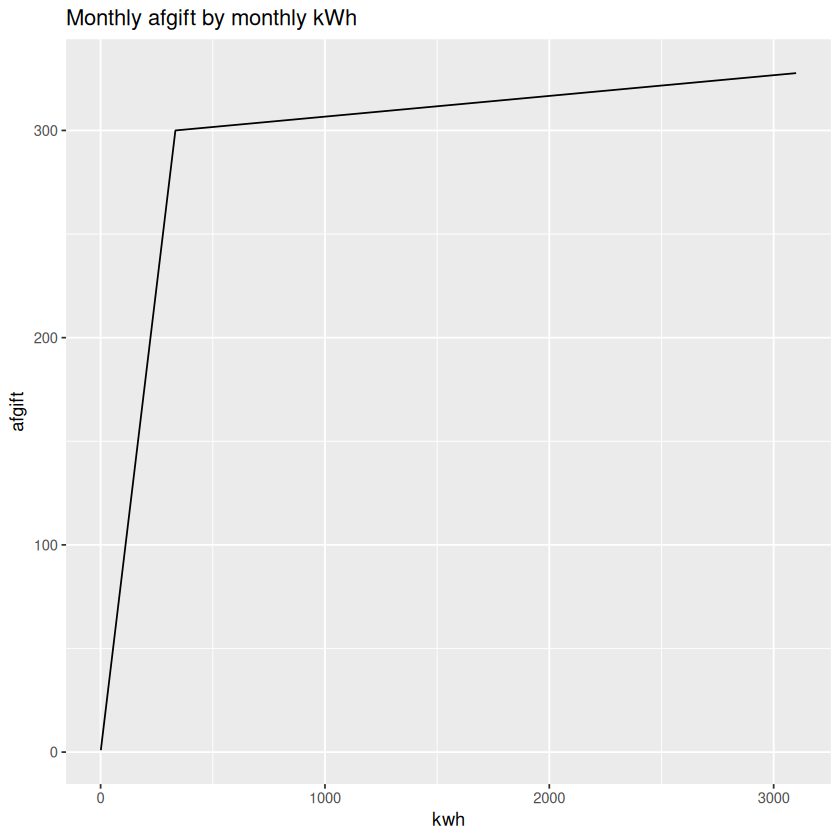

In [27]:
expand.grid(kwh=seq(100*31)) %>% 
  dplyr::mutate(over4k=case_when(kwh>(4000/12)~kwh-(4000/12),
                                 TRUE~0)) %>% 
  dplyr::mutate(under4k=case_when(kwh<=(4000/12)~kwh,
                                 TRUE~(4000/12))) %>% 
  dplyr::mutate(afgift=0.90*under4k+0.01*over4k) %>% 
  ggplot(aes(x=kwh,y=afgift)) +
  geom_line() +
  labs(title="Monthly afgift by monthly kWh")

# Total kWh price by total use

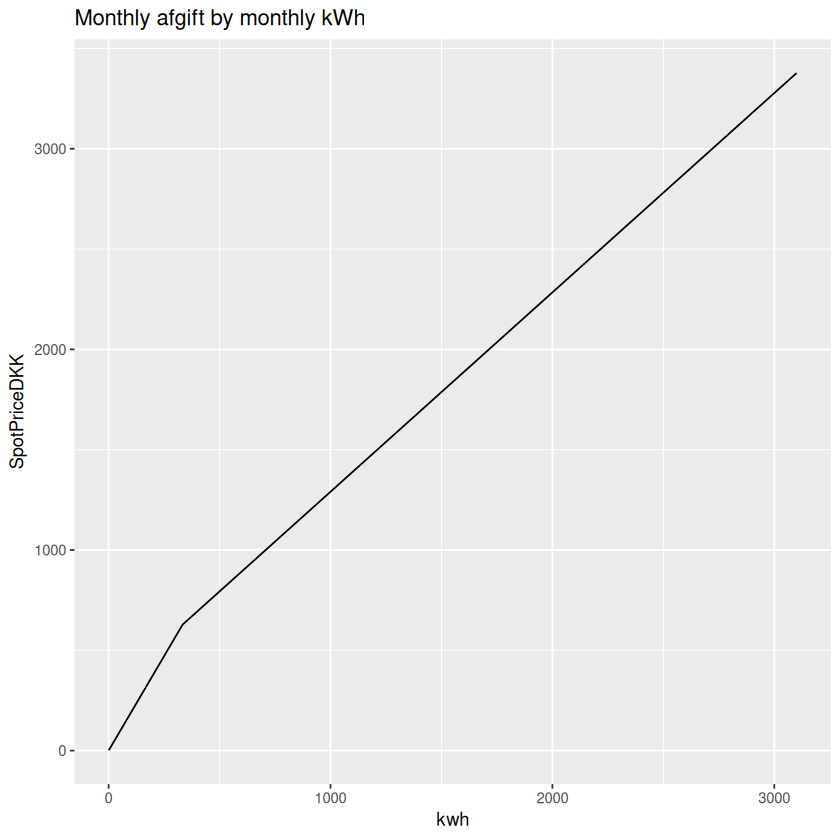

In [28]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-months(1)

mean_price_spot = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  dplyr::summarize(SpotPriceMean=mean(SpotPriceDKK_Total_SansAfgift)) %>% 
  pull(SpotPriceMean)

expand.grid(kwh=seq(100*31)) %>% 
  dplyr::mutate(over4k=case_when(kwh>(4000/12)~kwh-(4000/12),
                                 TRUE~0)) %>% 
  dplyr::mutate(under4k=case_when(kwh<=(4000/12)~kwh,
                                 TRUE~(4000/12))) %>% 
  dplyr::mutate(afgift=0.90*under4k+0.01*over4k) %>% 
  dplyr::mutate(SpotPriceDKK=kwh*mean_price_spot+afgift) %>% 
  ggplot(aes(x=kwh,y=SpotPriceDKK)) +
  geom_line() +
  labs(title="Monthly afgift by monthly kWh")

# Total kWh price by total use (outside 17-21)

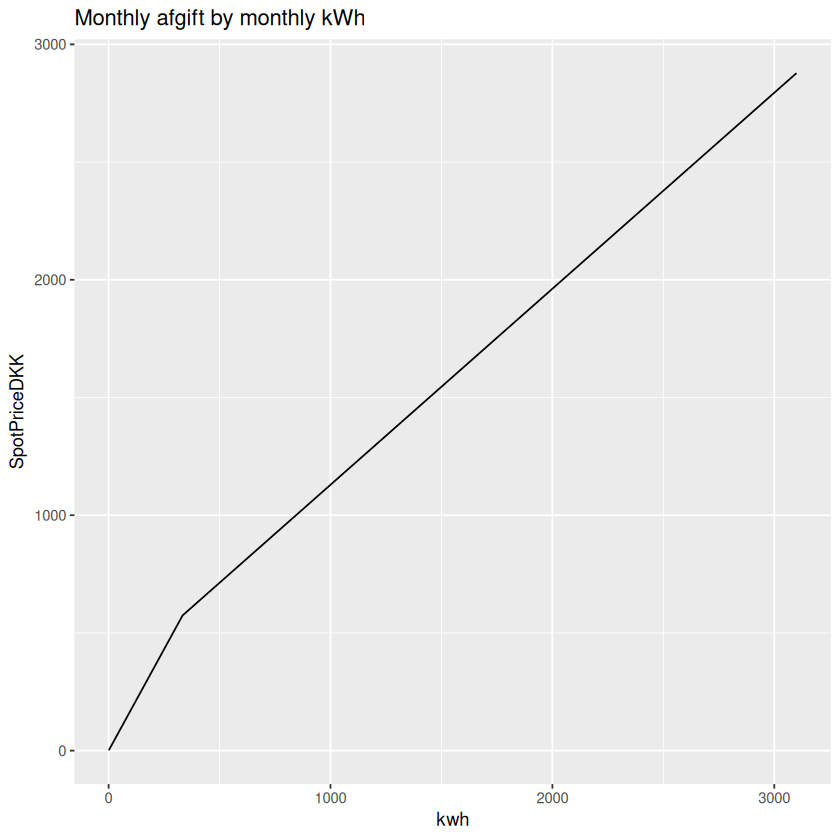

In [29]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-months(1)

mean_price_spot = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  filter(!Hour %in% c(17,18,19,20)) %>% 
  dplyr::summarize(SpotPriceMean=mean(SpotPriceDKK_Total_SansAfgift)) %>% 
  pull(SpotPriceMean)

expand.grid(kwh=seq(100*31)) %>% 
  dplyr::mutate(over4k=case_when(kwh>(4000/12)~kwh-(4000/12),
                                 TRUE~0)) %>% 
  dplyr::mutate(under4k=case_when(kwh<=(4000/12)~kwh,
                                 TRUE~(4000/12))) %>% 
  dplyr::mutate(afgift=0.90*under4k+0.01*over4k) %>% 
  dplyr::mutate(SpotPriceDKK=kwh*mean_price_spot+afgift) %>% 
  ggplot(aes(x=kwh,y=SpotPriceDKK)) +
  geom_line() +
  labs(title="Monthly afgift by monthly kWh")

# Average  kWh price by total use

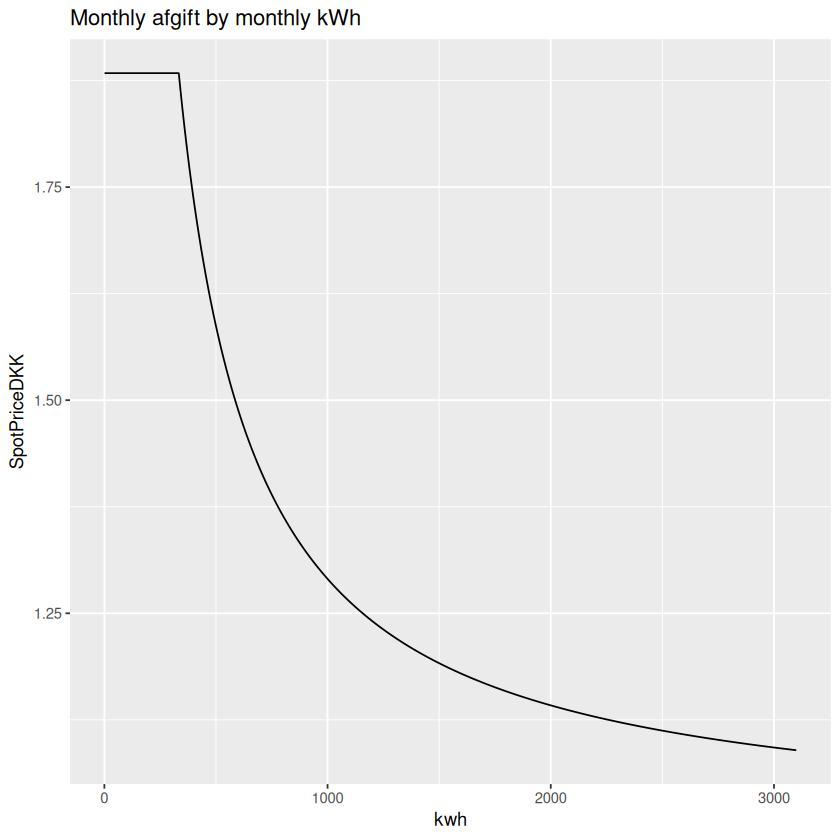

In [30]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-months(1)

mean_price_spot = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  dplyr::summarize(SpotPriceMean=mean(SpotPriceDKK_Total_SansAfgift)) %>% 
  pull(SpotPriceMean)

expand.grid(kwh=seq(100*31)) %>% 
  dplyr::mutate(over4k=case_when(kwh>(4000/12)~kwh-(4000/12),
                                 TRUE~0)) %>% 
  dplyr::mutate(under4k=case_when(kwh<=(4000/12)~kwh,
                                 TRUE~(4000/12))) %>% 
  dplyr::mutate(afgift=0.90*under4k+0.01*over4k) %>% 
  dplyr::mutate(SpotPriceDKK=kwh*mean_price_spot+afgift) %>% 
  dplyr::mutate(SpotPriceDKK=SpotPriceDKK/kwh) %>% 
  ggplot(aes(x=kwh,y=SpotPriceDKK)) +
  geom_line() +
  labs(title="Monthly afgift by monthly kWh")

# Average  kWh price by total use (outside 17-12)

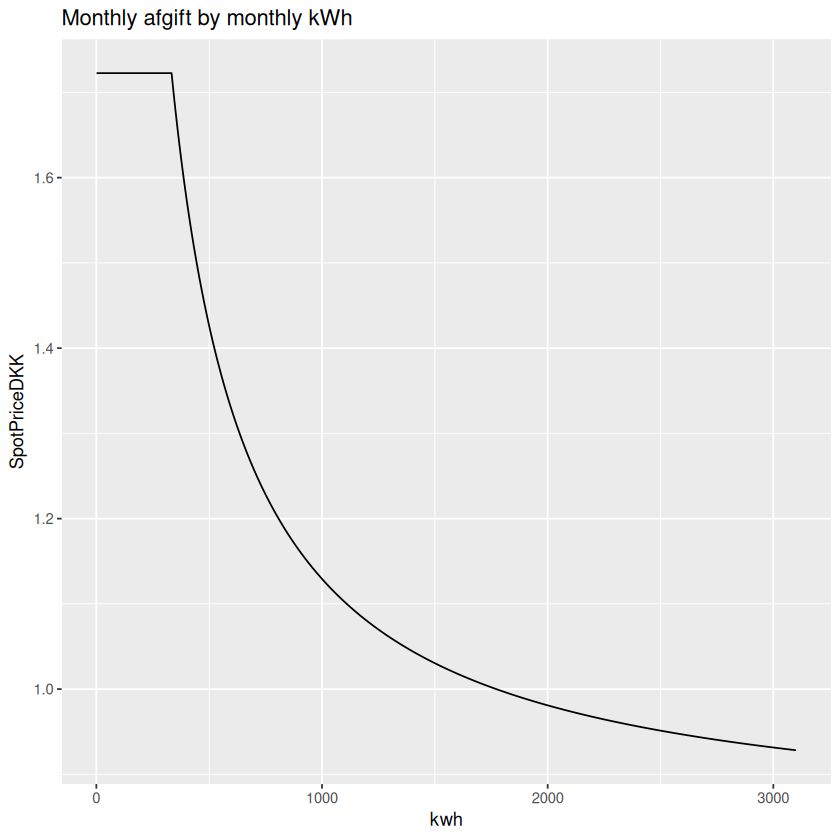

In [31]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = max_forecast_day-months(1)

mean_price_spot = df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(Day_Num=lubridate::floor_date(HourDK,unit = "day"),
                Hour=lubridate::hour(HourDK)) %>% 
  filter(!Hour %in% c(17,18,19,20)) %>% 
  dplyr::summarize(SpotPriceMean=mean(SpotPriceDKK_Total_SansAfgift)) %>% 
  pull(SpotPriceMean)

expand.grid(kwh=seq(100*31)) %>% 
  dplyr::mutate(over4k=case_when(kwh>(4000/12)~kwh-(4000/12),
                                 TRUE~0)) %>% 
  dplyr::mutate(under4k=case_when(kwh<=(4000/12)~kwh,
                                 TRUE~(4000/12))) %>% 
  dplyr::mutate(afgift=0.90*under4k+0.01*over4k) %>% 
  dplyr::mutate(SpotPriceDKK=kwh*mean_price_spot+afgift) %>% 
  dplyr::mutate(SpotPriceDKK=SpotPriceDKK/kwh) %>% 
  ggplot(aes(x=kwh,y=SpotPriceDKK)) +
  geom_line() +
  labs(title="Monthly afgift by monthly kWh")

# Send message

In [32]:
tmp_dir = tempdir()
ggsave(filename = paste0(tmp_dir,"/p1.jpg"),plot = p1,device = "jpeg")
pushoverr::pushover(message = "Electricity Forecast",attachment = paste0(tmp_dir,"/p1.jpg"))

# Best windows
msg_ = res %>% 
  dplyr::mutate(diff_hours=as.numeric(difftime(HourDK,as.POSIXct(Sys.Date()+hours(6),tz="Europe/Copenhagen"),units = "mins"))/60) %>% 
  dplyr::mutate(label_=glue("{window}H Window: {hour(HourDK)}:00 - {scales::number(rollingsum,accuracy=0.001)} DKK ({p_label}), Delay: {diff_hours}")) %>% 
  pull(label_) %>% 
  paste(.,collapse="\n")
msg_ = paste0("ELECTRICITY BEST WINDOWS:\n",msg_)
pushoverr::pushover(message = msg_)

Saving 6.67 x 6.67 in image
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
